In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import koreanize_matplotlib
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import gower

ModuleNotFoundError: No module named 'seaborn'

In [3]:
# 모든 열 다 보기
pd.set_option('display.max_columns', None)

# 너비 제한 없애기 (길게 나올 경우 줄바꿈 없이 한 줄에 표시)
pd.set_option('display.width', None)

NameError: name 'pd' is not defined

In [1]:
data = pd.read_csv(r"C:\Users\jeong\happycircuit\data\real_final_dataset.csv",encoding = "utf-8")

NameError: name 'pd' is not defined

In [20]:
# 사용할 변수 리스트 정의
selected_columns = [
    '시도교육청', '위도', '경도', '이용인원', '1학년 학생수','학교명','시군구',
    '1학년 학급당 학생수', '2학년 학생수', '2학년 학급당 학생수', '3학년 학생수', '3학년 학급당 학생수',
    '4학년 학생수', '4학년 학급당 학생수', '5학년 학생수', '5학년 학급당 학생수', '6학년 학생수',
    '6학년 학급당 학생수', '특수학급 학생수', '특수학급 학급당 학생수', '학생수(계)',
    '학급당 학생수(계)', '교사수', '수업교원 1인당 학생수', '다문화자녀수', '2023_총수입금액(백만원)',
    '교지면적(m)', '학생1인당교지면적', '이용비율'
]

# 원본 데이터에서 선택
data = data[selected_columns].copy()


In [21]:
# 데이터프레임 전체 결측치 확인
data.isnull().sum()

시도교육청               0
위도                  0
경도                  0
이용인원                0
1학년 학생수             0
학교명                 0
시군구                53
1학년 학급당 학생수         0
2학년 학생수             0
2학년 학급당 학생수         0
3학년 학생수             0
3학년 학급당 학생수         0
4학년 학생수             0
4학년 학급당 학생수         0
5학년 학생수             0
5학년 학급당 학생수         0
6학년 학생수             0
6학년 학급당 학생수         0
특수학급 학생수            0
특수학급 학급당 학생수        0
학생수(계)              0
학급당 학생수(계)          0
교사수                 0
수업교원 1인당 학생수        0
다문화자녀수              0
2023_총수입금액(백만원)    53
교지면적(m)             0
학생1인당교지면적           0
이용비율                0
dtype: int64

In [22]:
data = data.dropna()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 수치형 변수만 추출
numeric_data = data.select_dtypes(include=["float64", "int64"])

# 결측치 제거
#numeric_data = numeric_data.dropna()

# 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = numeric_data.columns
vif_df["VIF"] = [variance_inflation_factor(scaled_data, i) for i in range(scaled_data.shape[1])]

print(vif_df.sort_values(by="VIF", ascending=False))


           variable            VIF
17           학생수(계)  655864.930280
11          5학년 학생수   20927.264622
13          6학년 학생수   19176.315590
5           2학년 학생수   19154.916571
7           3학년 학생수   18108.503077
9           4학년 학생수   17586.170084
3           1학년 학생수   17291.888360
18       학급당 학생수(계)     221.378217
15         특수학급 학생수      88.744984
19              교사수      69.195614
20     수업교원 1인당 학생수      58.733830
12      5학년 학급당 학생수      14.855220
10      4학년 학급당 학생수      14.771631
8       3학년 학급당 학생수      14.756893
6       2학년 학급당 학생수      14.196759
14      6학년 학급당 학생수      13.264221
4       1학년 학급당 학생수      13.140100
25             이용비율       3.755501
16     특수학급 학급당 학생수       3.173337
2              이용인원       2.699370
24        학생1인당교지면적       2.149016
22  2023_총수입금액(백만원)       1.459003
21           다문화자녀수       1.308725
0                위도       1.241780
1                경도       1.160332
23          교지면적(m)       1.149808


In [24]:
# 사용할 변수 리스트 정의
selected_columns = [
    '시도교육청', '위도', '경도', '이용인원', '1학년 학생수',
    '1학년 학급당 학생수', '2학년 학생수', '2학년 학급당 학생수', '3학년 학생수', '3학년 학급당 학생수',
    '4학년 학생수', '4학년 학급당 학생수', '5학년 학생수', '5학년 학급당 학생수', '6학년 학생수',
    '6학년 학급당 학생수', '특수학급 학생수', '특수학급 학급당 학생수', '학생수(계)',
    '학급당 학생수(계)', '교사수', '수업교원 1인당 학생수', '다문화자녀수', '2023_총수입금액(백만원)',
    '교지면적(m)', '학생1인당교지면적', '이용비율'
]

# 원본 데이터에서 선택
sample_data = data[selected_columns].copy()

In [15]:
data.equals(sample_data)

True

C:\Users\jeong\AppData\Local\Temp\ipykernel_28052\766970047.py:15: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, method='average')


실루엣 점수: 0.3305
cluster
2    3800
1    1774
3     507
Name: count, dtype: int64


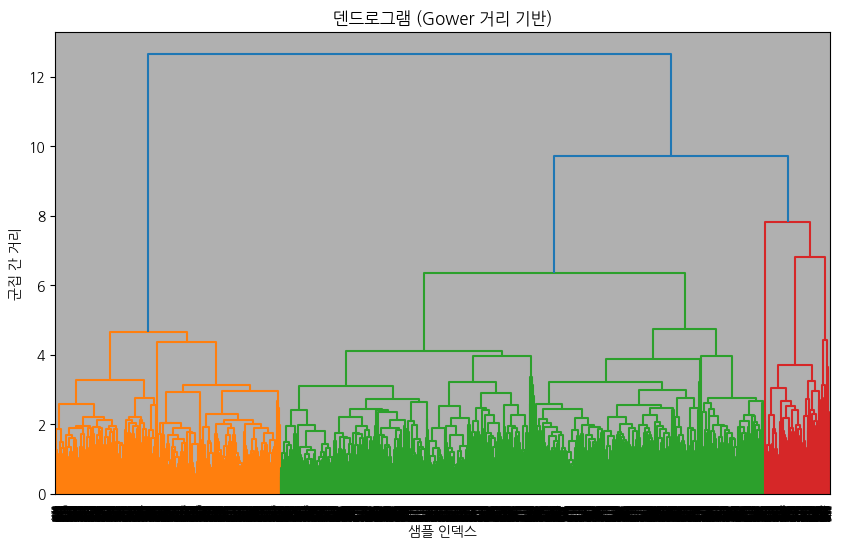

In [25]:
import pandas as pd
import numpy as np
import gower
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt



# 2. Gower 거리 계산
distance_matrix = gower.gower_matrix(sample_data)
distance_matrix = np.nan_to_num(distance_matrix, nan=1.0, posinf=1.0, neginf=1.0)

# 3. linkage 생성
linked = linkage(distance_matrix, method='average')

# 4. 군집 라벨 생성
cluster_labels = fcluster(linked, t=3, criterion='maxclust')

# 5. 실루엣 점수 계산
score = silhouette_score(distance_matrix, cluster_labels, metric='precomputed')
print(f"실루엣 점수: {score:.4f}")

# 6. 라벨 붙이기
#sample_data = sample_data.copy()
data["cluster"] = cluster_labels
print(data["cluster"].value_counts())

# 7. 덴드로그램 시각화
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("덴드로그램 (Gower 거리 기반)")
plt.xlabel("샘플 인덱스")
plt.ylabel("군집 간 거리")
plt.grid(True)
plt.show()

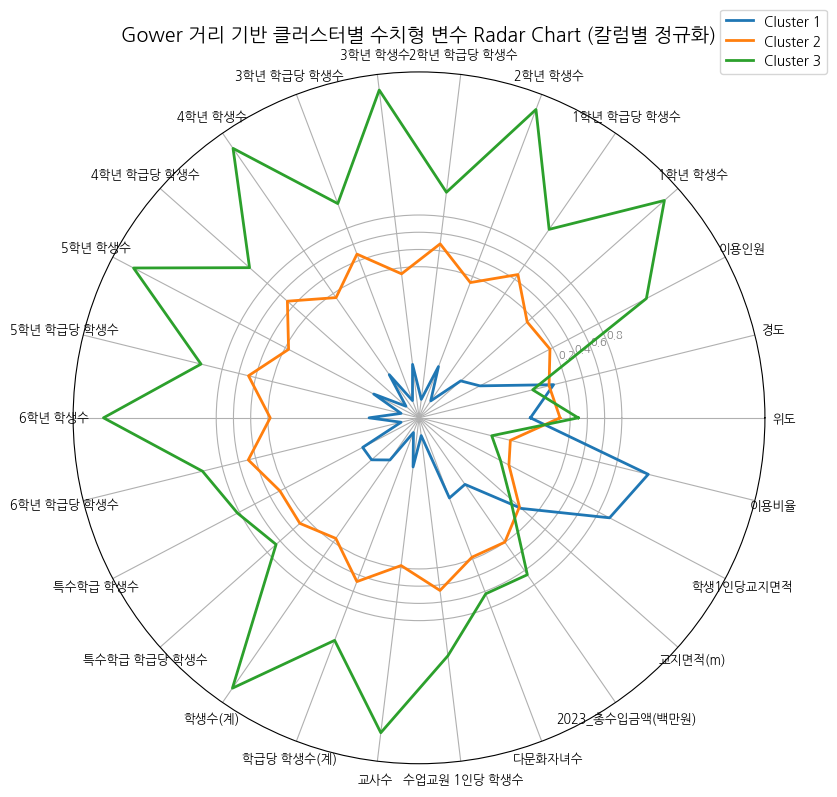

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 수치형 변수만 추출
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = [col for col in numeric_cols if col != "cluster"]

# 2. 수치형 변수만 따로 저장
data_numeric = data[numeric_cols]


# 3. 칼럼별로 표준화 (Standardization: 평균 0, 표준편차 1)
data_normalized = (data_numeric - data_numeric.mean()) / data_numeric.std()

# 4. 정규화된 데이터에 cluster 붙이기
data_normalized["cluster"] = data["cluster"].values

# 5. 군집별 평균 계산
cluster_means_norm = data_normalized.groupby("cluster").mean()

# 6. Radar Chart 그리기
labels = cluster_means_norm.columns.tolist()
labels.remove("cluster") if "cluster" in labels else None  # 혹시 cluster가 남아있으면 제거
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))
for i, row in cluster_means_norm.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    plt.polar(angles, values, label=f'Cluster {i}', linewidth=2)

plt.xticks(angles[:-1], labels, fontsize=9)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="gray", size=8)
plt.title("Gower 거리 기반 클러스터별 수치형 변수 Radar Chart (칼럼별 정규화)", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()


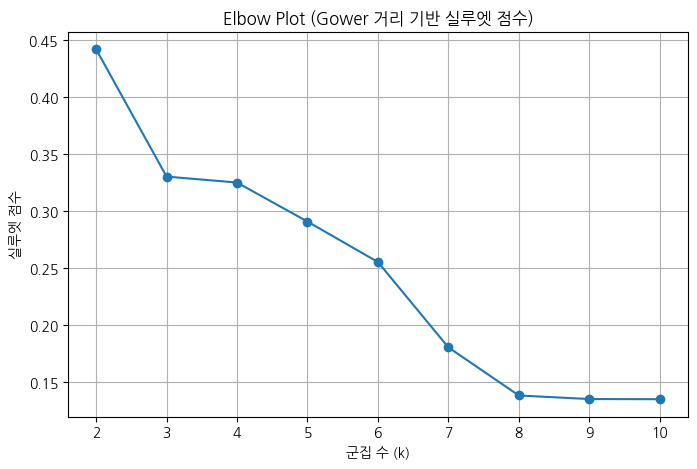

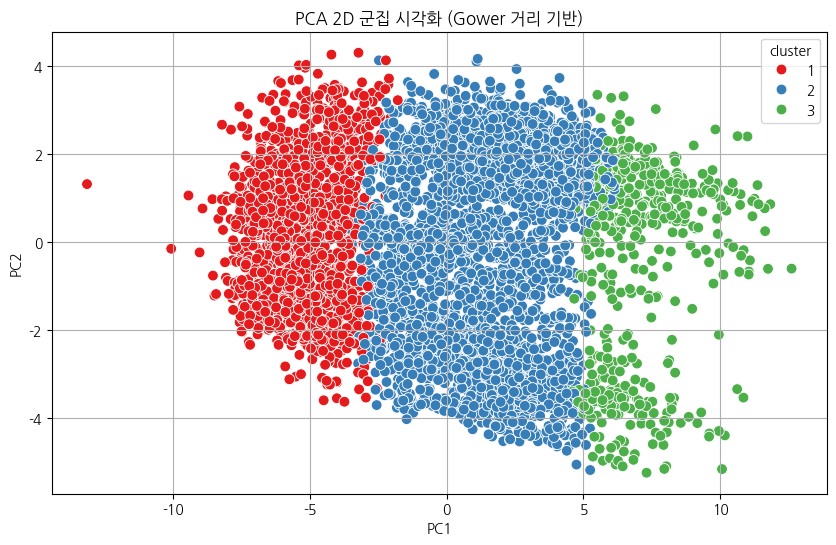

In [37]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import seaborn as sns

### 8. Elbow Plot: 실루엣 점수 기반으로 최적 군집 수 시각화
ks = range(2, 11)
silhouette_scores = []

for k in ks:
    labels = fcluster(linked, k, criterion='maxclust')
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(ks, silhouette_scores, marker='o')
plt.title("Elbow Plot (Gower 거리 기반 실루엣 점수)")
plt.xlabel("군집 수 (k)")
plt.ylabel("실루엣 점수")
plt.grid(True)
plt.show()

### 9. PCA 시각화 (원본 변수 기반으로 2차원 축소)
# 범주형 인코딩
sample_encoded = pd.get_dummies(data.drop(columns=["cluster"]), drop_first=True)

# 결측치 보간 (안정성을 위해)
imputer = SimpleImputer(strategy="mean")
imputed_data = imputer.fit_transform(sample_encoded)

# 스케일링 (선택적)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 결과 DataFrame
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["cluster"] = data["cluster"].values

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="Set1", s=60)
plt.title("PCA 2D 군집 시각화 (Gower 거리 기반)")
plt.grid(True)
plt.show()


cluster         1      2      3
시도교육청                          
강원특별자치도교육청  57.67  40.62   1.70
경기도교육청      13.55  73.49  12.95
경상남도교육청     39.36  53.68   6.96
경상북도교육청     52.94  42.23   4.83
광주광역시교육청     8.84  85.71   5.44
대구광역시교육청     2.16  87.45  10.39
대전광역시교육청     7.38  86.58   6.04
부산광역시교육청     9.03  84.28   6.69
서울특별시교육청     0.33  86.79  12.88
울산광역시교육청     9.92  82.64   7.44
인천광역시교육청     7.63  72.14  20.23
전라남도교육청     61.08  37.26   1.65
전북특별자치도교육청  55.91  42.61   1.48
제주특별자치도교육청  30.70  58.77  10.53
충청남도교육청     51.70  41.99   6.31
충청북도교육청     45.17  47.10   7.72


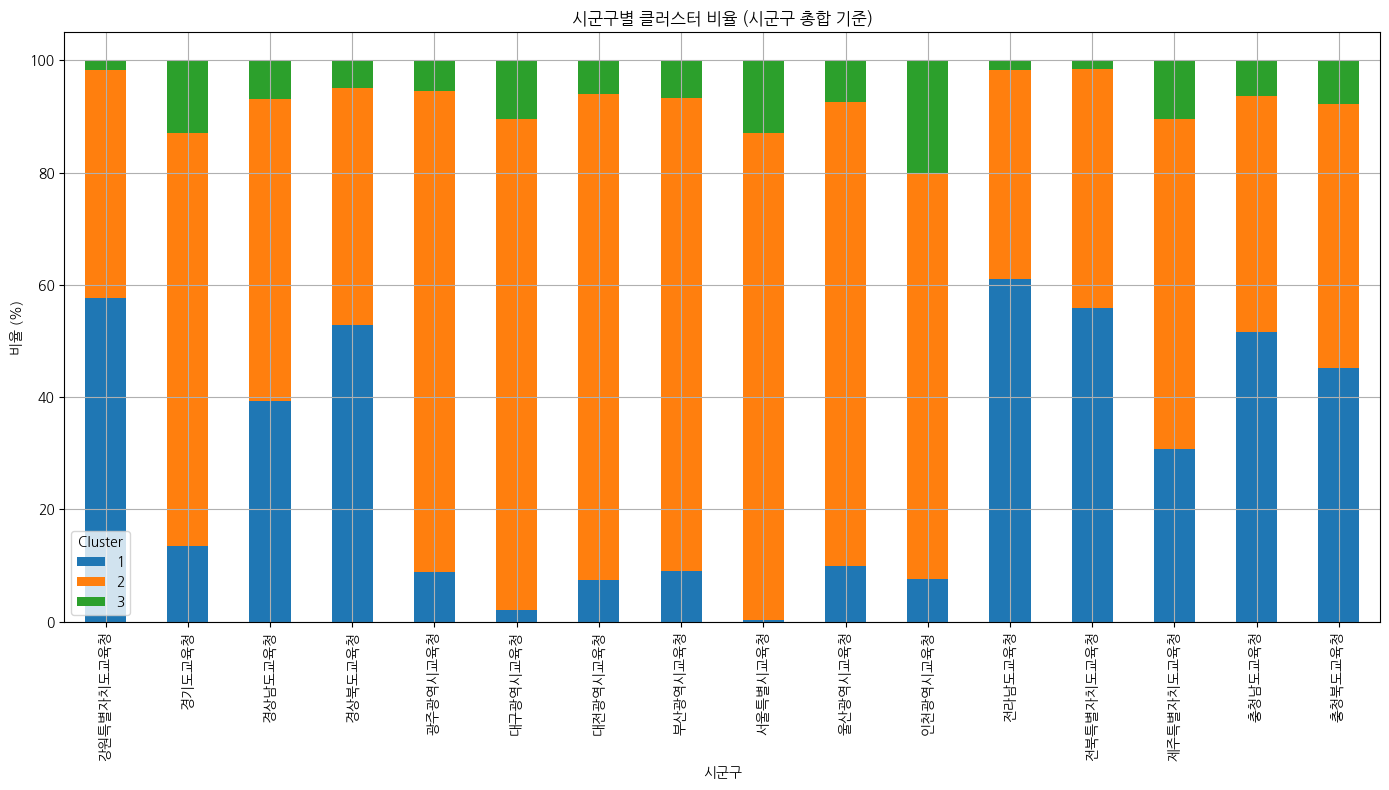

In [44]:
# 1. 시군구별 클러스터 수 세기
region_cluster_counts = data.groupby(["시도교육청", "cluster"]).size().unstack(fill_value=0)

# 2. 시군구별 총합 (시군구별 샘플 수)
region_total = region_cluster_counts.sum(axis=1)

# 3. 시군구별 클러스터 비율 계산
region_cluster_percent = region_cluster_counts.div(region_total, axis=0) * 100

# 4. 결과 출력
print(region_cluster_percent.round(2))  # 보기 좋게 소수점 2자리로

# 5. 필요하면 시각화
import matplotlib.pyplot as plt

region_cluster_percent.plot(kind="bar", stacked=True, figsize=(14, 8))
plt.title("시군구별 클러스터 비율 (시군구 총합 기준)")
plt.ylabel("비율 (%)")
plt.xlabel("시군구")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

